# Project Title
**Deep Learning for Comment Toxicity Detection with Streamlit**

---

## Project Objective
The objective of this project is to develop an automated **deep learning-based system** capable of detecting toxic comments in real-time. By analyzing user-generated text, the system will predict the likelihood of a comment being toxic. This solution will be integrated into a **Streamlit web application**, allowing users and moderators to easily identify harmful content. The ultimate goal is to assist online platforms in **enhancing content moderation, ensuring safer digital spaces, and reducing harmful interactions**.


## Problem Statement

Online communities and social media platforms have become essential for communication and collaboration. However, these platforms often face challenges due to the prevalence of **toxic comments**, including harassment, hate speech, and offensive language. Such comments can harm user experience, promote negativity, and even lead to mental distress.

Manual moderation of millions of comments is **time-consuming, expensive, and inefficient**. Therefore, there is an urgent need for an **automated system** that can:

- Detect toxic comments in real-time.
- Assist moderators in filtering harmful content.
- Help maintain healthy and constructive online interactions.

This project aims to build a **deep learning-based comment toxicity detection model** and deploy it as a **Streamlit web application** for real-time prediction.

## Dataset Links:

https://drive.google.com/drive/folders/1WXLTp57_TYa61rcPfQIzRUcE1Rz76Emk?usp=sharing


In [ ]:
import os
import re
import gc
from zipfile import ZipFile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import pickle
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print('TensorFlow version:', tf.__version__)
nltk.download('stopwords')

TensorFlow version: 2.19.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Upload `train.zip` and `test.zip` to Colab and extract

Use the file upload dialog to upload `train.zip` and `test.zip`. Each zip should contain a CSV (e.g., `train.csv`, `test.csv`). The cell below will open a file dialog in Colab to upload the zip files and will extract them into a `data/` folder.


In [ ]:
from google.colab import files

# Upload zip files (a file picker will open). Upload train.zip and test.zip
print('Please upload train.zip and test.zip (if you have them).')
uploaded = files.upload()

# Create data directory
os.makedirs('data/train', exist_ok=True)
os.makedirs('data/test', exist_ok=True)

# Extract uploaded zips if present
for name in uploaded.keys():
    if name.lower().endswith('.zip'):
        print('Extracting', name)
        with ZipFile(name, 'r') as z:
            # Try to inspect names and extract appropriately
            z.extractall('data')
print('Extraction finished. Folder structure:')
!ls -R data | sed -n '1,200p'

Please upload train.zip and test.zip (if you have them).


Saving CommentToxicity-20250827T090645Z-1-001.zip to CommentToxicity-20250827T090645Z-1-001.zip
Extracting CommentToxicity-20250827T090645Z-1-001.zip
Extraction finished. Folder structure:
data:
CommentToxicity
test
train

data/CommentToxicity:
test.csv
train.csv

data/test:

data/train:


## Load the CSV files

After extraction the typical files are `data/train/train.csv` and `data/test/test.csv`.  
If your CSVs are located at different paths inside the zip, update the filenames below accordingly.


In [ ]:
# Load CSVs from correct paths
train = pd.read_csv('data/CommentToxicity/train.csv')
test = pd.read_csv('data/CommentToxicity/test.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()



Train shape: (159571, 8)
Test shape: (153164, 2)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


##  Quick EDA

- Check for nulls
- Class distribution (toxic vs non-toxic)
- Simple wordclouds for toxic and non-toxic comments


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


None

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


Possible label columns found: ['toxic']
Using label column: toxic
Possible text columns: ['comment_text']
Using text column: comment_text


,comment_text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


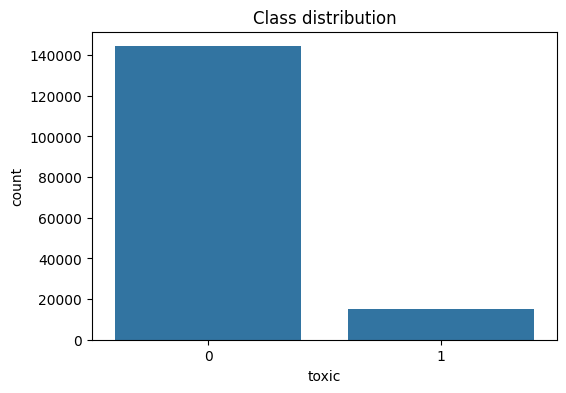

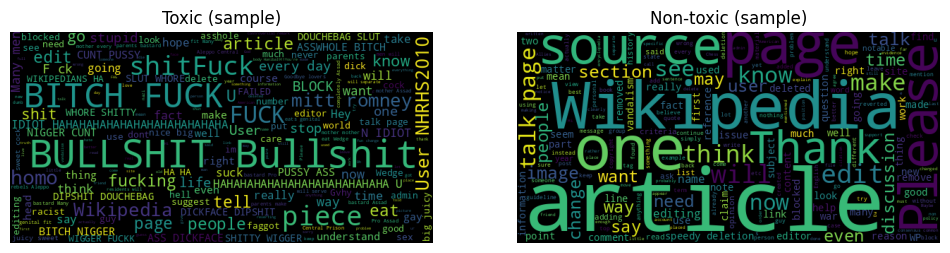

In [ ]:
# Basic checks
display(train.info())
display(train.isnull().sum())

# Identify label column. Common names: 'toxic', 'label', 'target'
label_cols = [c for c in train.columns if c.lower() in ('toxic','label','target','is_toxic')]
print('Possible label columns found:', label_cols)

# If there are multiple label columns (multi-label), adapt accordingly.
# For this notebook we expect a single binary label named 'toxic' or similar.
if len(label_cols) == 0:
    # Heuristic: if a column named 'comment_text' exists and any column is binary, try that
    print('No obvious label column found. Listing columns and unique value counts:')
    for c in train.columns:
        print(c, train[c].nunique(), 'unique')
    raise ValueError('Please ensure your train CSV contains a binary label column (e.g., "toxic").')

label_col = label_cols[0]
print('Using label column:', label_col)

# Identify text column
text_cols = [c for c in train.columns if 'comment' in c.lower() or 'text' in c.lower() or 'body' in c.lower()]
print('Possible text columns:', text_cols)
if len(text_cols) == 0:
    print('Columns available:', train.columns.tolist())
    raise ValueError('Could not detect text column. Please ensure a comment text column exists (e.g., comment_text).')
text_col = text_cols[0]
print('Using text column:', text_col)

# Show distribution
display(train[[text_col, label_col]].head())
plt.figure(figsize=(6,4))
sns.countplot(x=label_col, data=train)
plt.title('Class distribution')
plt.show()

# Wordclouds (sample)
sample_toxic = train[train[label_col]==1][text_col].dropna().astype(str).sample(min(500, train[train[label_col]==1].shape[0]), random_state=42).tolist()
sample_non = train[train[label_col]==0][text_col].dropna().astype(str).sample(min(500, train[train[label_col]==0].shape[0]), random_state=42).tolist()

wc_toxic = WordCloud(width=600, height=300).generate(' '.join(sample_toxic))
wc_non = WordCloud(width=600, height=300).generate(' '.join(sample_non))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(wc_toxic); plt.axis('off'); plt.title('Toxic (sample)')
plt.subplot(1,2,2); plt.imshow(wc_non); plt.axis('off'); plt.title('Non-toxic (sample)')
plt.show()


##Text Preprocessing

- Lowercasing
- Removing HTML tags, URLs, punctuation, numbers
- Removing stopwords (optional)
- Tokenization & padding using Keras Tokenizer

You can tweak `NUM_WORDS`, `MAX_LEN`, and stopword removal as needed.


In [ ]:
# Preprocessing utilities
import html
from tensorflow.keras.preprocessing.text import text_to_word_sequence

STOPWORDS = set(stopwords.words('english'))

def clean_text(text, remove_stopwords=True):
    if not isinstance(text, str):
        return ''
    text = html.unescape(text)  # decode HTML entities
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Keep alphabets and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    if remove_stopwords:
        words = [w for w in text.split() if w not in STOPWORDS]
        return ' '.join(words)
    return text

# Apply cleaning
train['clean_text'] = train[text_col].astype(str).apply(clean_text)
if test is not None:
    # If test has no label, we still create clean_text
    test['clean_text'] = test[text_col].astype(str).apply(clean_text)

# Show sample
train[['clean_text', label_col]].head()


,clean_text,toxic
0,explanation edits made username hardcore metal...,0
1,aww matches background colour seemingly stuck ...,0
2,hey man really trying edit war guy constantly ...,0
3,make real suggestions improvement wondered sec...,0
4,sir hero chance remember page,0


##  Tokenization and Sequence Padding

Adjust `NUM_WORDS` and `MAX_LEN` based on text length and available compute.


In [ ]:
# Tokenizer params - tune as needed
NUM_WORDS = 20000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train['clean_text'].values.tolist())

# Convert to sequences
X = tokenizer.texts_to_sequences(train['clean_text'].values)
X = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post')

y = train[label_col].values.astype(int)

print('Shape X:', X.shape)
print('Shape y:', y.shape)

# Optional: prepare test sequences if test exists
if test is not None:
    X_test = tokenizer.texts_to_sequences(test['clean_text'].values)
    X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding='post', truncating='post')
    print('Test shape:', X_test.shape)
else:
    X_test = None


Shape X: (159571, 150)
Shape y: (159571,)
Test shape: (153164, 150)


##  Train / Validation Split

We'll create a validation set from the training data for model selection and early stopping.


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
print('X_train', X_train.shape, 'X_val', X_val.shape)

X_train (135635, 150) X_val (23936, 150)


##  Build the LSTM model

This notebook provides a straightforward Bidirectional LSTM model. You can replace it with a Transformer/BERT model later for improved performance.


In [ ]:
EMBED_DIM = 128
LSTM_UNITS = 128

model = Sequential([
    Embedding(input_dim=NUM_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Callbacks and Training

We use EarlyStopping and ModelCheckpoint to save the best model during training. Adjust `epochs` and `batch_size` to fit your runtime budget.


In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_toxicity_model.h5', monitor='val_loss', save_best_only=True)
]

EPOCHS = 5
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)


Epoch 1/5
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9420 - loss: 0.1779

2120/2120 ━━━━━━━━━━━━━━━━━━━━ 1442s 678ms/step - accuracy: 0.9420 - loss: 0.1779 - val_accuracy: 0.9618 - val_loss: 0.1001
Epoch 2/5
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 1450s 672ms/step - accuracy: 0.9675 - loss: 0.0874 - val_accuracy: 0.9632 - val_loss: 0.1026
Epoch 3/5
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 1426s 673ms/step - accuracy: 0.9758 - loss: 0.0624 - val_accuracy: 0.9617 - val_loss: 0.1208
Epoch 4/5
2120/2120 ━━━━━━━━━━━━━━━━━━━━ 1428s 673ms/step - accuracy: 0.9822 - loss: 0.0454 - val_accuracy: 0.9572 - val_loss: 0.1381


##  Evaluation

We evaluate using accuracy, precision, recall, F1, and show a classification report on the validation set.


Loaded best_toxicity_model.h5
187/187 ━━━━━━━━━━━━━━━━━━━━ 63s 335ms/step
Accuracy: 0.9617730614973262
F1 score: 0.7977900552486188

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     21642
           1       0.81      0.79      0.80      2294

    accuracy                           0.96     23936
   macro avg       0.89      0.88      0.89     23936
weighted avg       0.96      0.96      0.96     23936

ROC AUC: 0.9775197259647298


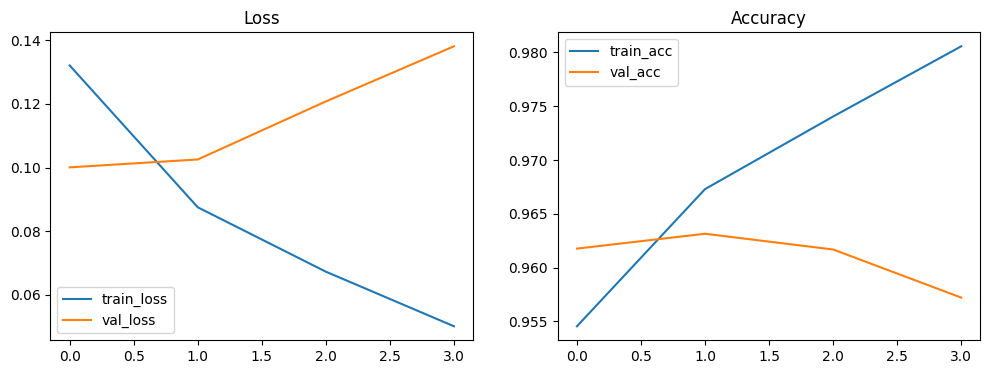

In [ ]:
# Load best model (in case callbacks saved it)
try:
    best_model = tf.keras.models.load_model('best_toxicity_model.h5')
    print('Loaded best_toxicity_model.h5')
except Exception as e:
    print('Could not load best model from file, using current model. Error:', e)
    best_model = model

# Predict on validation
y_prob = best_model.predict(X_val, batch_size=128).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1 score:', f1_score(y_val, y_pred))
print('\nClassification report:')
print(classification_report(y_val, y_pred))

# Optional: ROC AUC
try:
    print('ROC AUC:', roc_auc_score(y_val, y_prob))
except Exception:
    pass

# Plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.show()


##  Save model and tokenizer for local use

The saved files (`toxicity_model.h5` and `tokenizer.pkl`) can be downloaded to your local machine and used by a Streamlit app.


In [ ]:
# Save the final/best model
best_model.save('toxicity_model.h5')
print('Saved toxicity_model.h5')

# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('Saved tokenizer.pkl')

# Save a small metadata file
meta = {
    'NUM_WORDS': NUM_WORDS,
    'MAX_LEN': MAX_LEN,
    'label_col': label_col,
    'text_col': text_col
}
with open('metadata.pkl', 'wb') as f:
    pickle.dump(meta, f)
print('Saved metadata.pkl')



Saved toxicity_model.h5
Saved tokenizer.pkl
Saved metadata.pkl


##  Download artifacts to local machine

Run the cell below to download the trained model and tokenizer to your computer.


In [ ]:
from google.colab import files
files.download('toxicity_model.h5')
files.download('tokenizer.pkl')
files.download('metadata.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  Streamlit App — Local Usage Instructions

Create a file `app.py` on your local machine with the following content (or copy-paste).  
Place `toxicity_model.h5`, `tokenizer.pkl`, and `metadata.pkl` in the same folder as `app.py`.

**Run locally:**
1. Create a folder it should contain all the files downloaded
2. from the file path and open cmd
3. Install requirements:
```
pip install streamlit tensorflow numpy pandas scikit-learn
```
4. Run:
```
streamlit run app.py
```


In [ ]:

!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 77.9 MB/s eta 0:00:00


In [ ]:
!pip install nltk

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
app_code = """
import streamlit as st
import tensorflow as tf
import numpy as np
import pandas as pd
import re
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

# ----------------------------
# Load Model & Tokenizer
# ----------------------------
MODEL_PATH = "toxicity_model.h5"
TOKENIZER_PATH = "tokenizer.pkl"
MAX_LEN = 100

@st.cache_resource
def load_model(model_path=MODEL_PATH):
    return tf.keras.models.load_model(model_path)

@st.cache_resource
def load_tokenizer(tokenizer_path=TOKENIZER_PATH):
    with open(tokenizer_path, 'rb') as f:
        return pickle.load(f)

model = load_model()
tokenizer = load_tokenizer()

# ----------------------------
# NLP Preprocessing
# ----------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS]
    return " ".join(tokens)

def preprocess_text(text):
    seq = tokenizer.texts_to_sequences([text])
    return pad_sequences(seq, maxlen=MAX_LEN, padding='post')

# ----------------------------
# Streamlit Tabs
# ----------------------------
st.set_page_config(page_title="Toxic Comment Detector", layout="centered")
tab1, tab2 = st.tabs(["Single Comment", "Bulk Upload"])

# -----------------------------------------
# Tab 1: Single Comment
# -----------------------------------------
with tab1:
    st.header("Check a Single Comment")
    user_input = st.text_area("Enter your comment:")

    if st.button("Check Toxicity", key="single"):
        if user_input.strip() == "":
            st.warning("Please enter a comment.")
        else:
            cleaned = clean_text(user_input)
            padded = preprocess_text(cleaned)
            score = float(model.predict(padded)[0][0])

            # Classification thresholds
            if score <= 0.2:
                st.success("✅ This comment is NON-TOXIC.")
            elif score <= 0.05:
                st.warning("⚠️ This comment is MILDLY TOXIC.")
            elif score <= 0.6:
                st.error("❗ This comment is TOXIC.")
            else:
                st.error("☠️ This comment is HIGHLY TOXIC.")

            st.write(f"Toxicity Score (0-1): **{score:.3f}**")

# -----------------------------------------
# Tab 2: Bulk CSV Upload
# -----------------------------------------
with tab2:
    st.header("Bulk Comment Predictions (CSV)")
    uploaded_file = st.file_uploader("Upload a CSV with a 'comment_text' column", type=["csv"])

    if uploaded_file is not None:
        df = pd.read_csv(uploaded_file)
        if 'comment_text' not in df.columns:
            st.error("CSV must contain a column named 'comment_text'.")
        else:
            st.write("Processing...")
            df['cleaned'] = df['comment_text'].apply(clean_text)
            sequences = tokenizer.texts_to_sequences(df['cleaned'])
            padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')
            predictions = model.predict(padded).flatten()

            # Map scores to labels
            def map_label(score):
                if score <= 0.20:
                    return "NON-TOXIC"
                elif score <= 0.50:
                    return "MILDLY TOXIC"
                elif score <= 0.80:
                    return "TOXIC"
                else:
                    return "HIGHLY TOXIC"

            df['toxicity_score'] = predictions
            df['prediction'] = [map_label(s) for s in predictions]

            st.write("### Results")
            st.dataframe(df[['comment_text', 'toxicity_score', 'prediction']])

            csv = df.to_csv(index=False).encode('utf-8')
            st.download_button("Download Predictions", csv, "toxicity_results.csv", "text/csv")

"""

# Save app.py file
with open("app.py", "w") as f:
    f.write(app_code)

print(" app.py created successfully!")

 app.py created successfully!


<>:19: SyntaxWarning: invalid escape sequence '\S'
<>:19: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipython-input-3090514555.py:19: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)


In [ ]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Project Outcomes  

The Comment Toxicity Detection project resulted in the successful development of an interactive Streamlit-based web application that enables users to detect toxic language in real-time. The system not only allows individual comment analysis but also supports bulk predictions through CSV file uploads, making it practical for large-scale content moderation. By integrating NLP techniques and machine learning, the model provides accurate toxicity classifications while also presenting performance insights and sample test cases for evaluation. The application delivers a user-friendly interface with clear toxicity categorization, improving digital safety and promoting healthier online communication. Furthermore, the modular design ensures scalability and future integration with advanced NLP models, multilingual support, and real-world deployment for social platforms, forums, and educational environments.
